In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modules import data_loader, metrics, learning, plotting, utils, params, pipelines
import matplotlib.pyplot as plt
import numpy as np
import torch
from modules.gmp_model import BatchGMP
from modules.nn_model import GRU, LSTM, CustomTCN, TorchESN, DenseNetRegressor, BayesianLSTM, BayesianDense, BayesianDense_noLRT




Load data from files and init acpr meter

In [3]:
data = data_loader.load_data("DPA_200MHz")

config = data["config"]
fs = config["input_signal_fs"]
bw_main_ch = config["bw_main_ch"]
bw_sub_ch = config["bw_sub_ch"]
n_sub_ch = config["n_sub_ch"]
sub_ch = config["sub_ch"]
nperseg = config["nperseg"]

x_train = data["train_input"]
y_train = data["train_output"]
x_val = data["val_input"]
y_val = data["val_output"]

gain = metrics.calculate_gain_complex(x_train, y_train)
print(f"PA gain = {gain:.2f}")
y_train_target = gain * x_train
y_val_target = gain * x_val

data['y_train_target'] = y_train_target
data['y_val_target'] = y_val_target

acpr_meter = metrics.ACPR(
        sample_rate=fs,
        main_measurement_bandwidth=bw_main_ch,
        adjacent_channel_offset=[-sub_ch, sub_ch],
        segment_length=nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )


PA gain = 2.52


In [55]:
frame_length = 64
batch_size = 256
batch_size_eval = 2048
train_size = x_train.shape[0]

pa_train_loader, pa_val_loader = data_loader.build_dataloaders(data_dict=data, frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval)
dla_train_loader, dla_val_loader = data_loader.build_dataloaders(data_dict=data, frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval, arch="dla")
ila_train_loader, ila_val_loader = data_loader.build_dataloaders(data_dict=data, frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval, arch="ila")

criterion = metrics.compute_mse
metric_criterion = metrics.compute_nmse

In [66]:
class SparseLSTM(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, thresh, config="DCC"):
        super().__init__()
        self.lstm = BayesianLSTM(incoming=input_dim,
                                 num_units=hidden_dim,
                                 config=config,
                                 only_return_final=False,
                                 thresh=thresh)
        self.dense = BayesianDense(incoming=hidden_dim, 
                                   num_units=output_dim, 
                                   thresh=thresh)
    
    @utils.complex_handler
    def forward(self, x):
        lstm_out = self.lstm(x)
        y = self.dense(lstm_out)
        return y

    def compute_compression_masks(self):
        """
        Возвращает маски компрессии в виде torch.Tensor.
        Маски отвязаны от графа вычислений (detach).
        """

        masks_lstm = self.lstm.get_ard()
        masks_dense = self.dense.get_ard()

        mask_vocabulary = masks_lstm["z_input"].to(dtype=torch.bool)

        mask_hidden = torch.logical_or(
            masks_lstm["z_hidden_by_w"],
            masks_dense["w"].any(dim=1)
        )
        mask_hidden = torch.logical_and(mask_hidden, masks_lstm["z_hidden"])
        mask_hidden = mask_hidden.to(dtype=torch.bool)

        w_in = masks_lstm["w_input"].clone()
        w_hid = masks_lstm["w_hidden"].clone()
        w_dense = masks_dense["w"].clone()
        gates = masks_lstm["gates"].clone()

        w_in[:, ~mask_vocabulary, :] = 0
        w_in[:, :, ~mask_hidden] = 0
        w_hid[:, ~mask_hidden, :] = 0
        w_hid[:, :, ~mask_hidden] = 0
        w_dense[~mask_hidden] = 0
        gates[:, ~mask_hidden] = 0

        return mask_vocabulary, mask_hidden, gates, w_in, w_hid, w_dense

    def evaluate_compression(self):
        mask_vocabulary, mask_hidden, mask_gates, mask_w_inp, mask_w_hid, mask_w_dense = self.compute_compression_masks()
        
        w_nonzero, w_all = 0.0, 0.0
        for w in [mask_w_inp, mask_w_hid, mask_w_dense]:
            w_nonzero += float(w.sum())
            w_all += float(w.numel())
        overall_compression = w_all / (w_nonzero + 1e-8)

        print("Compression per layers:")
        for layer_name, masks in [("LSTM", {"z_x":mask_vocabulary, "z_h":mask_hidden, "gates":mask_gates, "w_x":mask_w_inp, "w_h":mask_w_hid}), ("Dense", {"w":mask_w_dense})]:
            print(layer_name, end=": ")
            for key, matrix in masks.items():
                print("(%s: %d/%d)" % (key, int(matrix.sum()), matrix.numel()), end=" ")
            print()
        print(f"Overall compression: {overall_compression:.3f}")
        return overall_compression


import time

class LMTrainer():
    def __init__(self, 
                 model,
                 optimizer,
                 criterion,
                 val_criterion=None,
                 num_epochs=100,
                 train_loader=None,
                 valid_loader=None,
                 test_loader=None,
                 train_size=1,
                 grad_clip=1.0,
                 lambda_reg=1,
                 print_fq=1,
                 save_fq=0,
                 log_interval=100):
        
        self.model = model
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.test_loader = test_loader
        self.optimizer = optimizer
        self.criterion = criterion
        self.val_criterion = val_criterion if val_criterion else criterion
        self.num_epochs = num_epochs
        self.grad_clip = grad_clip
        self.lambda_reg = lambda_reg
        self.print_fq = print_fq
        self.save_fq = save_fq
        self.sparsification_eval_fun=model.evaluate_compression if hasattr(model, "evaluate_compression") else None
        self.log_interval = log_interval
        self.train_size = train_size
        self.num_batches = len(train_loader)
        
        self.base_loss_ema = 1.0
        self.reg_loss_ema = 1.0
        self.ema_decay = 0.99
        
    def evaluate(self, loader, criterion):
        self.model.eval()
        loss_sum = 0.0
        tokens = 0
        with torch.no_grad():
            for batch in loader:
                xb, yb, *rest = batch
                mask = rest[0] if rest else None
                logits = self.model(xb)
                base_loss = criterion(logits, yb)
                # reg = self.get_reg()
                loss = base_loss
                loss_sum += loss.item() * yb.numel()
                tokens += yb.numel()
        self.model.train()
        return (loss_sum / tokens) if tokens > 0 else None
    
    def get_reg(self):
        reg = sum(
            [layer.eval_reg(self.train_size) 
            for layer in self.model.modules() 
            if hasattr(layer, "eval_reg")])
        return reg
    
    def train(self):
        for epoch in range(1, self.num_epochs + 1):
            epoch_start = time.perf_counter()
            self.model.train()
            total_loss_weighted = 0.0
            total_tokens = 0
            grad_norm = 0.0

            for batch_idx, batch in enumerate(self.train_loader):
                xb, yb, *rest = batch   # rest = [] или [mask]
                mask = rest[0] if rest else None
                self.optimizer.zero_grad()           
                logits = self.model(xb)
                base_loss = self.criterion(logits, yb)
                reg = self.get_reg()
                
                self.base_loss_ema = self.ema_decay * self.base_loss_ema + (1 - self.ema_decay) * base_loss.item()
                self.reg_loss_ema = self.ema_decay * self.reg_loss_ema + (1 - self.ema_decay) * reg.item()
                scale = self.base_loss_ema / (self.reg_loss_ema + 1e-8)
                loss = base_loss + reg * scale
                
                # loss = base_loss + self.lambda_reg * reg
                loss.backward()
                total_norm = torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                self.optimizer.step()

                loss_item = loss.item()
                n_tokens = yb.numel()
                total_loss_weighted += loss_item * n_tokens
                total_tokens += n_tokens

                grad_norm = max(grad_norm, torch.norm(
                    torch.stack([p.grad.norm() for p in self.model.parameters() if p.grad is not None])
                ).item())

                # if (batch_idx % self.log_interval == 0) or (batch_idx == self.num_batches - 1):
                #     print(
                #         f"  epoch {epoch:04d}/{self.num_epochs} | batch {batch_idx:04d}/{self.num_batches} | "
                #         f"base_loss {base_loss.item():.4f} | total_loss {loss_item:.4f} | tokens {n_tokens} "
                #     )

            avg_train_loss = total_loss_weighted / total_tokens if total_tokens > 0 else float("nan")
            epoch_time = time.perf_counter() - epoch_start

            self.print_epoch_metrics(epoch, epoch_time, avg_train_loss, grad_norm)

            if self.sparsification_eval_fun is not None:
                self.sparsification_eval_fun()
    
    def print_epoch_metrics(self, epoch, epoch_time, train_loss, grad_norm):
        do_print = (epoch % self.print_fq == 0) or (epoch == self.num_epochs)
        if do_print:
            val_loss = self.evaluate(self.valid_loader, self.val_criterion) if self.valid_loader is not None else None
            test_loss = self.evaluate(self.test_loader, self.val_criterion) if self.test_loader is not None else None

            val_str = f"{val_loss:.4f}" if val_loss is not None else "n/a"
            test_str = f"{test_loss:.4f}" if test_loss is not None else "n/a"

            print(
                f"Epoch {epoch:03d} | Time {epoch_time:.2f}s | Train {train_loss:.4f} | "
                f"grad_norm {grad_norm:.4f} | Val {val_str} | Test {test_str}"
            )

In [ ]:
# class SVDLossFn(torch.nn.Module):
#     def __init__(self, model, loss_fn, train_size, is_print=False):
#         super().__init__()
#         self.model = model
#         self.loss_fn = loss_fn
#         self.train_size = train_size
#         self.is_print = is_print
        
#     def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
#         base_loss = self.loss_fn(x, y)
#         reg = self.get_reg()
#         loss = base_loss + reg
#         if self.is_print:
#             print(f"base_loss: {10 * torch.log10(base_loss)}")
#         return loss
    
#     def get_reg(self):
#         reg = sum(
#             [layer.eval_reg(self.train_size) 
#             for layer in self.model.modules() 
#             if hasattr(layer, "eval_reg")])
#         return reg

PA

In [7]:

criterion_pa = metrics.compute_nmse

pa_degree = 5
pa_config = params.make_gmp_params(
    Ka=pa_degree,
    La=pa_degree,
    Kb=pa_degree,
    Lb=pa_degree,
    Mb=pa_degree,
    Kc=pa_degree,
    Lc=pa_degree,
    Mc=pa_degree,
)

pa_model = BatchGMP(**pa_config, model_name="pa")


print(f"total_params: {pa_model.count_params()}")

epochs = 10
lr = 0.001

optimizer = torch.optim.Adam(pa_model.parameters(), lr=lr)

if not pa_model.load_weights():
      learning.train(net=pa_model, 
            criterion=criterion_pa, 
            optimizer=optimizer, 
            train_loader=pa_train_loader, 
            val_loader=pa_val_loader, 
            n_epochs=epochs, 
            metric_criterion=metric_criterion)
      pa_model.save_weights()
utils.freeze_pa_model(pa_model)

y_val_pa = learning.net_inference(net=pa_model, x=x_val)
pa_nmse = metrics.compute_nmse(y_val_pa, y_val)
print(f"Model NMSE: {pa_nmse:.2f}")

total_params: 550
Coefficients loaded from model_params/pa_BatchGMP_Ka5_La5_Kb5_Lb5_Mb5_Kc5_Lc5_Mc5.pt
Model NMSE: -30.68


In [ ]:
# pa_train_loader = [(x_train, y_train)]
# pa_val_loader = [(x_val, y_val)]


epochs = 20
lr = 0.01
pa_model = SparseLSTM(input_dim=2, hidden_dim=64, output_dim=2, thresh=1, config='LCC')

total_params = sum(p.numel() for p in pa_model.parameters() if p.requires_grad)
print(f"total_params: {total_params}")

optimizer = torch.optim.Adam(pa_model.parameters(), lr=lr)

lm_trainer = LMTrainer(model=pa_model,
                                optimizer=optimizer,
                                criterion=criterion,
                                val_criterion=metric_criterion,
                                num_epochs=epochs,
                                # lambda_reg=1e-3,
                                train_loader=pa_train_loader,
                                valid_loader=pa_val_loader,
                                test_loader=pa_val_loader)

lm_trainer.train()

# criterion = SVDLossFn(model=pa_model, loss_fn=metrics.compute_mse, train_size=train_size, is_print=True)

# train(model=pa_model, optimizer=optimizer, train_loader=pa_train_loader, num_epochs=epochs)

# learning.train(net=pa_model, 
#       criterion=criterion, 
#       optimizer=optimizer, 
#       train_loader=pa_train_loader, 
#       val_loader=pa_val_loader, 
#       grad_clip_val=1.0, 
#       n_epochs=epochs, 
#       metric_criterion=metric_criterion)

utils.freeze_pa_model(pa_model)
y_val_pa = learning.net_inference(net=pa_model, x=x_val)
pa_nmse = metrics.compute_nmse(y_val_pa, y_val)
print(f"Model NMSE: {pa_nmse:.2f}")

total_params: 34434


In [32]:
with torch.autograd.profiler.profile(use_cuda=False) as prof:
    with torch.no_grad():
        output = pa_model.forward(x_val)

print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=20))

---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                  aten::mul        15.97%     219.790ms        25.98%     357.532ms       3.879us         92174  
                  aten::add        16.24%     223.532ms        24.12%     331.876ms       3.600us         92176  
                aten::slice        16.34%     224.797ms        19.80%     272.487ms       2.217us        122892  
                   aten::to         3.55%      48.884ms        18.09%     248.981ms       3.602us         69125  
             aten::_to_copy         7.74%     106.512ms        14.54%     200.097ms       4.342us         46085  
                aten::chunk         0.92%      12.665ms        10.11%     139.174ms     

In [ ]:

pa_model = CustomTCN(
    num_inputs=2,
    output_projection=2,
    num_channels=[32]*4,  # глубина и ширина сети, например, 4 слоя по 32 канала
    kernel_size=4,
    dropout=0.2,
    input_shape='NLC',
    causal=True,
    model_name="pa"
)

total_params = sum(p.numel() for p in pa_model.parameters())
print(f"total_params: {total_params}")

epochs = 100
lr = 0.0001

is_load = pa_model.load_weights()
optimizer = torch.optim.Adam(pa_model.parameters(), lr=lr)

if not is_load:
    learning.train(net=pa_model, 
        criterion=criterion, 
        optimizer=optimizer, 
        train_loader=pa_train_loader, 
        val_loader=pa_val_loader, 
        grad_clip_val=1.0, 
        n_epochs=epochs, 
        metric_criterion=metric_criterion)
    pa_model.save_weights()


utils.freeze_pa_model(pa_model)
y_val_pa = learning.net_inference(net=pa_model, x=x_val)
pa_nmse = metrics.compute_nmse(y_val_pa, y_val)
print(f"Model NMSE: {pa_nmse:.2f}")

total_params: 29602
Model weights loaded from model_params/pa_tcn_model_ch[32, 32, 32, 32]_ks4_in2_out2.pt


KeyboardInterrupt: 

c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


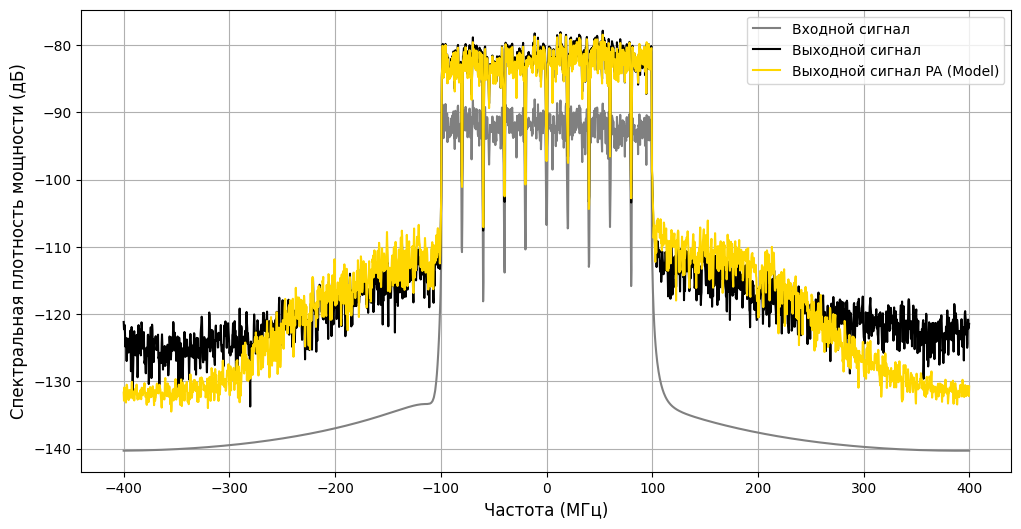

In [39]:
freqs, spectrum_x_val = metrics.power_spectrum(x_val, fs, nperseg)
_, spectrum_y_val = metrics.power_spectrum(y_val, fs, nperseg)
_, spectrum_pa = metrics.power_spectrum(y_val_pa, fs, nperseg)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_x_val)), color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val)), color='black', label='Выходной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_pa)), color='gold', label='Выходной сигнал PA (Model)')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()


DLA DPD

In [ ]:
epochs = 200
lr = 0.0001
# gru_dla = GRU(hidden_size=8, num_layers=1, model_name="dla")
gru_dla = CustomTCN(
    num_inputs=2,
    output_projection=2,
    num_channels=[16]*4,
    kernel_size=4,
    dropout=0.2,
    input_shape='NLC',
    causal=True,
    model_name="dla"
)
is_load = gru_dla.load_weights()
casc_gru_dla = utils.CascadeModel(model_1=gru_dla, model_2=pa_model)

optimizer_gru = torch.optim.Adam(casc_gru_dla.parameters(), lr=lr)

if not is_load:
    learning.train(net=casc_gru_dla, 
                   criterion=criterion, 
                   optimizer=optimizer_gru, 
                   train_loader=dla_train_loader, 
                   val_loader=dla_val_loader, 
                   grad_clip_val=1.0, 
                   n_epochs=epochs, 
                   metric_criterion=metric_criterion)
    gru_dla.save_weights()

y_val_gru_dla = learning.net_inference(net=casc_gru_dla, x=x_val)
gru_dla_nmse = metrics.compute_nmse(y_val_gru_dla, y_val_target)
print(f"Model NMSE: {gru_dla_nmse:.2f}")


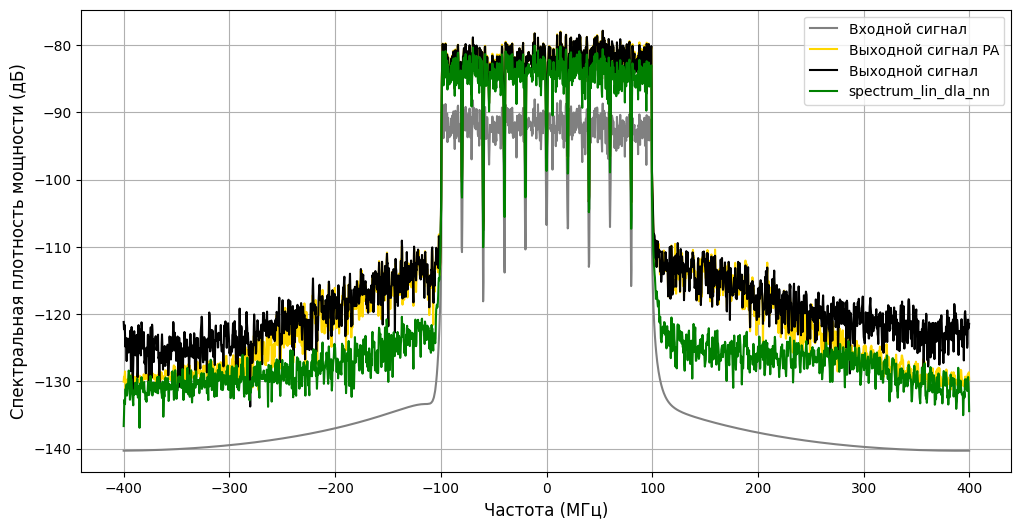

In [ ]:
freqs, spectrum_x_val = metrics.power_spectrum(x_val, fs, nperseg)
_, spectrum_y_val = metrics.power_spectrum(y_val, fs, nperseg)
_, spectrum_y_val_gru_pa = metrics.power_spectrum(y_val_pa, fs, nperseg)
_, spectrum_lin_dla_nn = metrics.power_spectrum(y_val_gru_dla, fs, nperseg)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_x_val)), color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_pa)), color='gold', label='Выходной сигнал PA')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val)), color='black', label='Выходной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_lin_dla_nn)), color='green', label='spectrum_lin_dla_nn')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()


ILA DPD grad

In [ ]:
epochs = 300
lr = 0.001
# gru_ila = GRU(hidden_size=8, num_layers=1, model_name="ila")
gru_ila = CustomTCN(
    num_inputs=2,
    output_projection=2,
    num_channels=[32]*4,
    kernel_size=4,
    dropout=0.2,
    input_shape='NLC',
    causal=True,
    model_name="ila"
)
is_load = gru_ila.load_weights()
casc_gru_ila_train = utils.CascadeModel(model_1=pa_model, model_2=gru_ila, gain=gain, cascade_type="ila")

optimizer_gru = torch.optim.Adam(casc_gru_ila_train.parameters(), lr=lr)

if not is_load:
    learning.train(net=casc_gru_ila_train, 
                   criterion=criterion, 
                   optimizer=optimizer_gru, 
                   train_loader=ila_train_loader, 
                   val_loader=ila_val_loader, 
                   grad_clip_val=1.0, 
                   n_epochs=epochs, 
                   metric_criterion=metric_criterion)
    gru_ila.save_weights()
    
casc_gru_ila_eval = utils.CascadeModel(model_1=gru_ila, model_2=pa_model)
y_val_gru_ila = learning.net_inference(net=casc_gru_ila_eval, x=x_val)
gru_ila_nmse = metrics.compute_nmse(y_val_gru_ila, y_val_target)
print(f"Model NMSE: {gru_ila_nmse:.2f}")


No saved weights found at model_params/ila_tcn_model_ch[32, 32, 32, 32]_ks4_in2_out2.pt, initializing new parameters.
===Start training===
Epoch 0000 — train_loss: 0.044637, val_loss: 0.006295, val_NMSE: -12.90
Epoch 0001 — train_loss: 0.008004, val_loss: 0.002277, val_NMSE: -17.32
Epoch 0002 — train_loss: 0.003960, val_loss: 0.000942, val_NMSE: -21.15
Epoch 0003 — train_loss: 0.002358, val_loss: 0.000579, val_NMSE: -23.26
Epoch 0004 — train_loss: 0.001598, val_loss: 0.000399, val_NMSE: -24.88
Epoch 0005 — train_loss: 0.001215, val_loss: 0.000319, val_NMSE: -25.85
Epoch 0006 — train_loss: 0.000973, val_loss: 0.000302, val_NMSE: -26.08
Epoch 0007 — train_loss: 0.000812, val_loss: 0.000295, val_NMSE: -26.19
Epoch 0008 — train_loss: 0.000698, val_loss: 0.000215, val_NMSE: -27.56
Epoch 0009 — train_loss: 0.000613, val_loss: 0.000211, val_NMSE: -27.64
Epoch 0010 — train_loss: 0.000549, val_loss: 0.000210, val_NMSE: -27.67
Epoch 0011 — train_loss: 0.000496, val_loss: 0.000173, val_NMSE: -28.

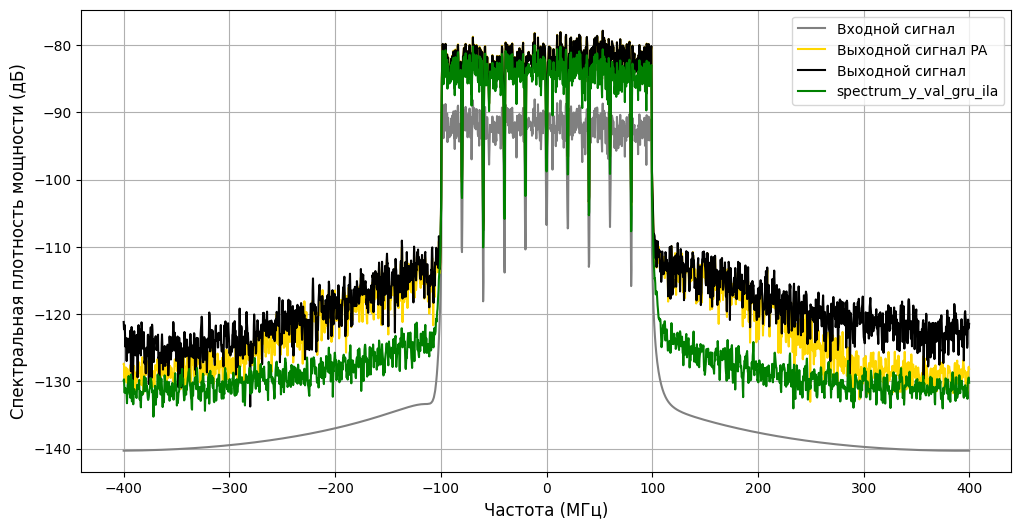

In [ ]:
freqs, spectrum_x_val = metrics.power_spectrum(x_val, fs, nperseg)
_, spectrum_y_val = metrics.power_spectrum(y_val, fs, nperseg)
_, spectrum_y_val_gru_pa = metrics.power_spectrum(y_val_pa, fs, nperseg)
_, spectrum_y_val_gru_ila = metrics.power_spectrum(y_val_gru_ila, fs, nperseg)
_, spectrum_y_val_target = metrics.power_spectrum(y_val_target, fs, nperseg)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_x_val)), color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_pa)), color='gold', label='Выходной сигнал PA')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val)), color='black', label='Выходной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_lin_dla_nn)), color='green', label='spectrum_y_val_gru_ila')
# plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_target)), color='magenta', label='spectrum_y_val_target')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()


ILC DPD

In [ ]:
u_k_train = learning.ilc_signal(x_train, y_train_target, pa_model, epochs=200, learning_rate=0.01)
u_k_val = learning.ilc_signal(x_val, y_val_target, pa_model, epochs=200, learning_rate=0.01)
u_k_pa = pa_model.forward(u_k_train).detach()

nmse_uk_pa = metrics.compute_nmse(u_k_pa, y_train_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

data["ilc_train_output"] = u_k_train
data["ilc_val_output"] = u_k_val

ilc_train_loader, ilc_val_loader = data_loader.build_dataloaders(data_dict=data, 
                                                                 frame_length=frame_length, 
                                                                 batch_size=batch_size, 
                                                                 batch_size_eval=batch_size_eval, 
                                                                 arch="ilc")

Epoch [0/200], Loss: 0.030799303203821182
Epoch [100/200], Loss: 3.4745031030070095e-07
Epoch [199/200], Loss: 1.2164208008924593e-11
Выполнение заняло: 0:00:16
Epoch [0/200], Loss: 0.030444536358118057
Epoch [100/200], Loss: 3.371440584487573e-07
Epoch [199/200], Loss: 1.2013976619096312e-11
Выполнение заняло: 0:00:07
NMSE на выходе усилителя (ILC): -108.42 db


In [ ]:
epochs = 300
lr = 0.001
# gru_ilc = GRU(hidden_size=8, num_layers=1, model_name="ilc")
gru_ilc = CustomTCN(
    num_inputs=2,
    output_projection=2,
    num_channels=[32]*4,
    kernel_size=4,
    dropout=0.2,
    input_shape='NLC',
    causal=True,
    model_name="ilc"
)

is_load = gru_ilc.load_weights()

optimizer_gru = torch.optim.Adam(gru_ilc.parameters(), lr=lr)

if not is_load:
    learning.train(net=gru_ilc, 
                   criterion=criterion, 
                   optimizer=optimizer_gru, 
                   train_loader=ilc_train_loader, 
                   val_loader=ilc_val_loader, 
                   grad_clip_val=1.0, 
                   n_epochs=epochs, 
                   metric_criterion=metric_criterion)
    gru_ilc.save_weights()

casc_gru_ilc_eval = utils.CascadeModel(model_1=gru_ilc, model_2=pa_model)
y_val_gru_ilc = learning.net_inference(net=casc_gru_ilc_eval, x=x_val)
gru_ilc_nmse = metrics.compute_nmse(y_val_gru_ilc, y_val_target)
print(f"Model NMSE: {gru_ilc_nmse:.2f}")


No saved weights found at model_params/ilc_tcn_model_ch[32, 32, 32, 32]_ks4_in2_out2.pt, initializing new parameters.
===Start training===
Epoch 0000 — train_loss: 0.015657, val_loss: 0.001512, val_NMSE: -17.09
Epoch 0001 — train_loss: 0.002441, val_loss: 0.000427, val_NMSE: -22.58
Epoch 0002 — train_loss: 0.001245, val_loss: 0.000226, val_NMSE: -25.35
Epoch 0003 — train_loss: 0.000801, val_loss: 0.000156, val_NMSE: -26.95
Epoch 0004 — train_loss: 0.000568, val_loss: 0.000113, val_NMSE: -28.34
Epoch 0005 — train_loss: 0.000431, val_loss: 0.000097, val_NMSE: -29.01
Epoch 0006 — train_loss: 0.000344, val_loss: 0.000084, val_NMSE: -29.65
Epoch 0007 — train_loss: 0.000287, val_loss: 0.000085, val_NMSE: -29.56
Epoch 0008 — train_loss: 0.000249, val_loss: 0.000066, val_NMSE: -30.69
Epoch 0009 — train_loss: 0.000219, val_loss: 0.000065, val_NMSE: -30.74
Epoch 0010 — train_loss: 0.000197, val_loss: 0.000062, val_NMSE: -30.93
Epoch 0011 — train_loss: 0.000180, val_loss: 0.000060, val_NMSE: -31.

c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


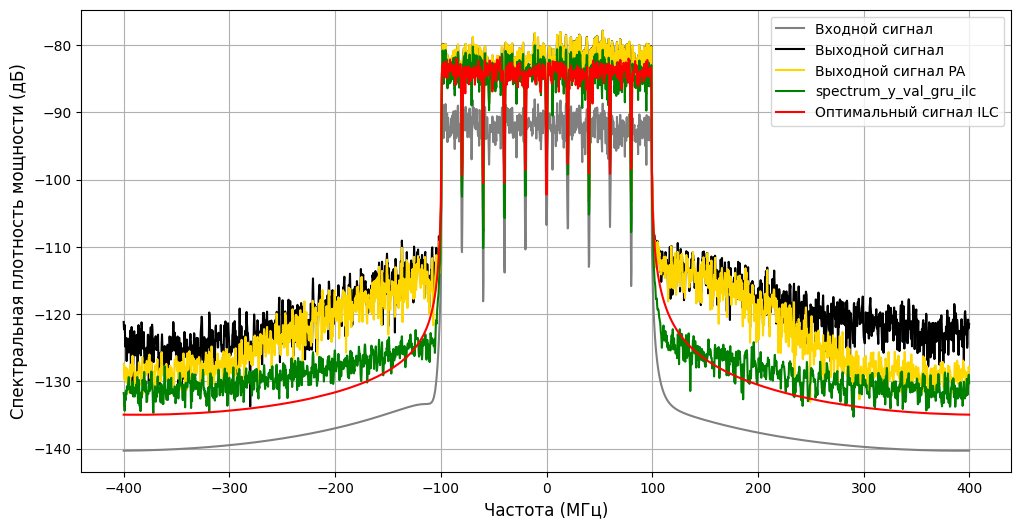

In [ ]:
freqs, spectrum_x_val = metrics.power_spectrum(x_val, fs, nperseg)
_, spectrum_y_val = metrics.power_spectrum(y_val, fs, nperseg)
_, spectrum_y_val_gru_pa = metrics.power_spectrum(y_val_pa, fs, nperseg)
_, spectrum_y_val_gru_ilc = metrics.power_spectrum(y_val_gru_ilc, fs, nperseg)
_, spectrum_y_val_target = metrics.power_spectrum(y_val_target, fs, nperseg)
_, spectrum_u_k_pa = metrics.power_spectrum(u_k_pa, fs, nperseg)
# _, spectrum_u_k = metrics.power_spectrum(u_k_train, fs, nperseg)


xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_x_val)), color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val)), color='black', label='Выходной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_pa)), color='gold', label='Выходной сигнал PA')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_ilc)), color='green', label='spectrum_y_val_gru_ilc')
# plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_u_k)), color='magenta', label='spectrum_u_k')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_u_k_pa)), color='red', label='Оптимальный сигнал ILC')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()


Metrics

In [ ]:
nmse_after_pa = metrics.compute_nmse(y_val_pa, y_val_target)

print(f"NMSE на выходе усилителя (без DPD): {nmse_after_pa:.2f} db")
print(f"NMSE на выходе усилителя (DLA DPD): {gru_dla_nmse:.2f} db")
print(f"NMSE на выходе усилителя (ILA DPD): {gru_ila_nmse:.2f} db")
print(f"NMSE на выходе усилителя (ILC DPD): {gru_ilc_nmse:.2f} db")

NMSE на выходе усилителя (без DPD): -14.09 db
NMSE на выходе усилителя (DLA DPD): -42.09 db
NMSE на выходе усилителя (ILA DPD): -41.56 db
NMSE на выходе усилителя (ILC DPD): -42.67 db


In [ ]:
x_val_acpr = metrics.calculate_acpr(x_val, acpr_meter)
y_val_acpr = metrics.calculate_acpr(y_val, acpr_meter)
y_val_pa_acpr = metrics.calculate_acpr(y_val_pa, acpr_meter)
y_val_target_acpr = metrics.calculate_acpr(y_val_target, acpr_meter)

y_lin_dla_acpr = metrics.calculate_acpr(y_val_gru_dla, acpr_meter)
y_lin_ila_acpr = metrics.calculate_acpr(y_val_gru_ila, acpr_meter)
y_lin_ilc_acpr = metrics.calculate_acpr(y_val_gru_ilc, acpr_meter)

print(f"x_val_acpr: {x_val_acpr}")
print(f"y_val_acpr: {y_val_acpr}")
print(f"y_val_pa_acpr: {y_val_pa_acpr}")
print(f"y_val_target_acpr: {y_val_target_acpr}")

print(f"lin_dla_acpr: {y_lin_dla_acpr}")
print(f"lin_ila_acpr: {y_lin_ila_acpr}")
print(f"lin_ilc_acpr: {y_lin_ilc_acpr}")


x_val_acpr: [-48.08083195 -48.40122574]
y_val_acpr: [-40.60778184 -38.20237847]
y_val_pa_acpr: [-42.78085016 -42.3951539 ]
y_val_target_acpr: [-48.08083304 -48.40122404]
lin_dla_acpr: [-46.60417735 -46.80978669]
lin_ila_acpr: [-46.592601  -46.8887058]
lin_ilc_acpr: [-46.67006903 -46.96768001]


In [ ]:
nmse_uk_pa = metrics.compute_nmse(u_k_pa, y_train_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

u_k_acpr = metrics.calculate_acpr(u_k_train, acpr_meter)
u_k_pa_acpr = metrics.calculate_acpr(u_k_pa, acpr_meter)

print(f"u_k_acpr: {u_k_acpr}")
print(f"u_k_pa_acpr: {u_k_pa_acpr}")

NMSE на выходе усилителя (ILC): -108.42 db
u_k_acpr: [-43.92685981 -42.93146017]
u_k_pa_acpr: [-50.93609073 -50.36968318]


Spectrum

In [ ]:
freqs, spectrum_x_val = metrics.power_spectrum(x_val, fs, nperseg)
_, spectrum_y_val = metrics.power_spectrum(y_val, fs, nperseg)
_, spectrum_y_val_gru_pa = metrics.power_spectrum(y_val_pa, fs, nperseg)
_, spectrum_y_val_target = metrics.power_spectrum(y_val_target, fs, nperseg)

_, spectrum_y_val_gru_dla = metrics.power_spectrum(y_val_gru_dla, fs, nperseg)
_, spectrum_y_val_gru_ila = metrics.power_spectrum(y_val_gru_ila, fs, nperseg)
_, spectrum_y_val_gru_ilc = metrics.power_spectrum(y_val_gru_ilc, fs, nperseg)

_, spectrum_u_k = metrics.power_spectrum(u_k_train, fs, nperseg)
_, spectrum_u_k_pa = metrics.power_spectrum(u_k_pa, fs, nperseg)

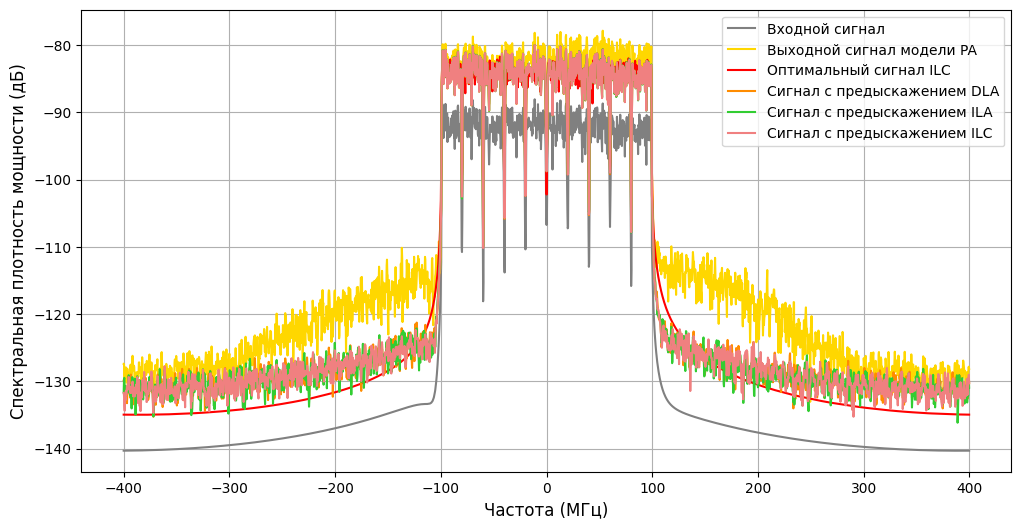

In [ ]:
# построение спектра

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_x_val)), color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_pa)), color='gold', label='Выходной сигнал модели PA')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_u_k_pa)), color='red', label='Оптимальный сигнал ILC')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_dla)), color='darkorange', label='Сигнал с предыскажением DLA')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_ila)), color='limegreen', label='Сигнал с предыскажением ILA')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_ilc)), color='lightcoral', label='Сигнал с предыскажением ILC')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()



In [ ]:
# moving_average
window_size = 60

freqs_s, spectrum_x_val_s = utils.moving_average(spectrum_x_val, freqs, fs, window_size)
_, spectrum_y_val_s = utils.moving_average(spectrum_y_val, freqs, fs, window_size)
_, spectrum_y_val_gru_pa_s = utils.moving_average(spectrum_y_val_gru_pa, freqs, fs, window_size)
_, spectrum_y_val_target_s = utils.moving_average(spectrum_y_val_target, freqs, fs, window_size)

# _, spectrum_y_val_gru_dla_s = utils.moving_average(spectrum_y_val_gru_dla, freqs, fs, window_size)
# _, spectrum_y_val_gru_ila_s = utils.moving_average(spectrum_y_val_gru_ila, freqs, fs, window_size)
# _, spectrum_y_val_gru_ilc_s = utils.moving_average(spectrum_y_val_gru_ilc, freqs, fs, window_size)

_, spectrum_y_val_gru_dla_s = utils.moving_average(spectrum_y_val_gru_dla, freqs, fs, window_size)
_, spectrum_y_val_gru_ila_s = utils.moving_average(spectrum_y_val_gru_ila, freqs, fs, window_size)
_, spectrum_y_val_gru_ilc_s = utils.moving_average(spectrum_y_val_gru_ilc, freqs, fs, window_size)

_, spectrum_u_k_s = utils.moving_average(spectrum_u_k, freqs, fs, window_size)
_, spectrum_u_k_pa_s = utils.moving_average(spectrum_u_k_pa, freqs, fs, window_size)



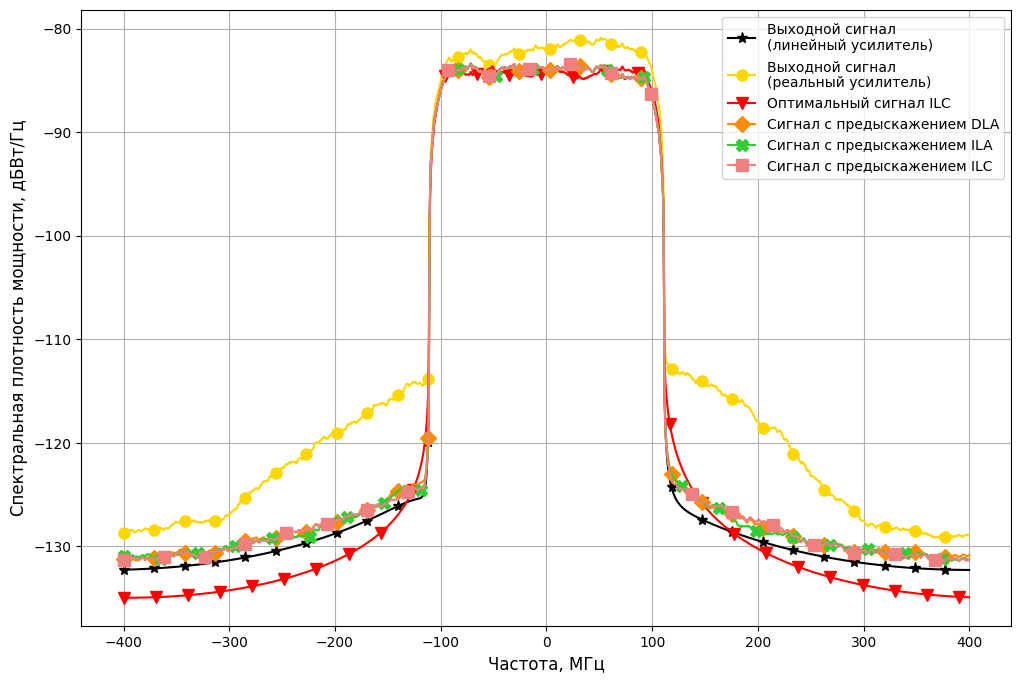

In [ ]:
# (сглаженный) построение спектра

xlabel="Частота, МГц"
ylabel= "Спектральная плотность мощности, дБВт/Гц"
fontsize = 12
figsize=(12, 8)
markersize=8

plt.figure(figsize=figsize)

# plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_x_val_s)), 
#          color='grey', label='Входной сигнал',marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_target_s)), 
         color='black', label='Выходной сигнал\n(линейный усилитель)',marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_pa_s)), 
         color='gold', label='Выходной сигнал\n(реальный усилитель)', marker='o', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_u_k_pa_s)), 
         color='red', label='Оптимальный сигнал ILC', marker='v', markevery=95, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_dla_s)), 
         color='darkorange', label='Сигнал с предыскажением DLA', marker='D', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_ila_s)), 
         color='limegreen', label='Сигнал с предыскажением ILA', marker='X', markevery=110, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_ilc_s)), 
         color='lightcoral', label='Сигнал с предыскажением ILC', marker='s', markevery=120, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()


AM/AM & AM/PM

In [ ]:
y_in_am_am, y_out_am_am = metrics.calculate_am_am(x_val, y_val)
y_in_am_pm, y_in_phase_am_pm = metrics.calculate_am_pm(x_val, y_val)

_, y_pa_am_am = metrics.calculate_am_am(x_val, y_val_pa)
_, y_pa_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_pa)

_, y_val_target_am_am = metrics.calculate_am_am(x_val, y_val_target)
_, y_val_target_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_target)

# x_in_am_am, u_k_am_am = metrics.calculate_am_am(x_in_tensor, u_k)
# x_in_am_pm, u_k_phase_am_pm = metrics.calculate_am_pm(x_in_tensor, u_k)

# _, u_k_pa_am_am = metrics.calculate_am_am(x_in_tensor, u_k_pa)
# _, u_k_pa_phase_am_pm = metrics.calculate_am_pm(x_in_tensor, u_k_pa)

# dpd
# _, y_val_gru_dla_am_am = metrics.calculate_am_am(x_val, y_val_gru_dla)
# _, y_val_gru_dla_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_dla)

# _, y_val_gru_ila_am_am = metrics.calculate_am_am(x_val, y_val_gru_ila)
# _, y_val_gru_ila_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_ila)

# _, y_val_gru_ilc_am_am = metrics.calculate_am_am(x_val, y_val_gru_ilc)
# _, y_val_gru_ilc_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_ilc)

#linearized
_, y_val_gru_dla_am_am = metrics.calculate_am_am(x_val, y_val_gru_dla)
_, y_val_gru_dla_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_dla)

_, y_val_gru_ila_am_am = metrics.calculate_am_am(x_val, y_val_gru_ila)
_, y_val_gru_ila_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_ila)

_, y_val_gru_ilc_am_am = metrics.calculate_am_am(x_val, y_val_gru_ilc)
_, y_val_gru_ilc_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_ilc)


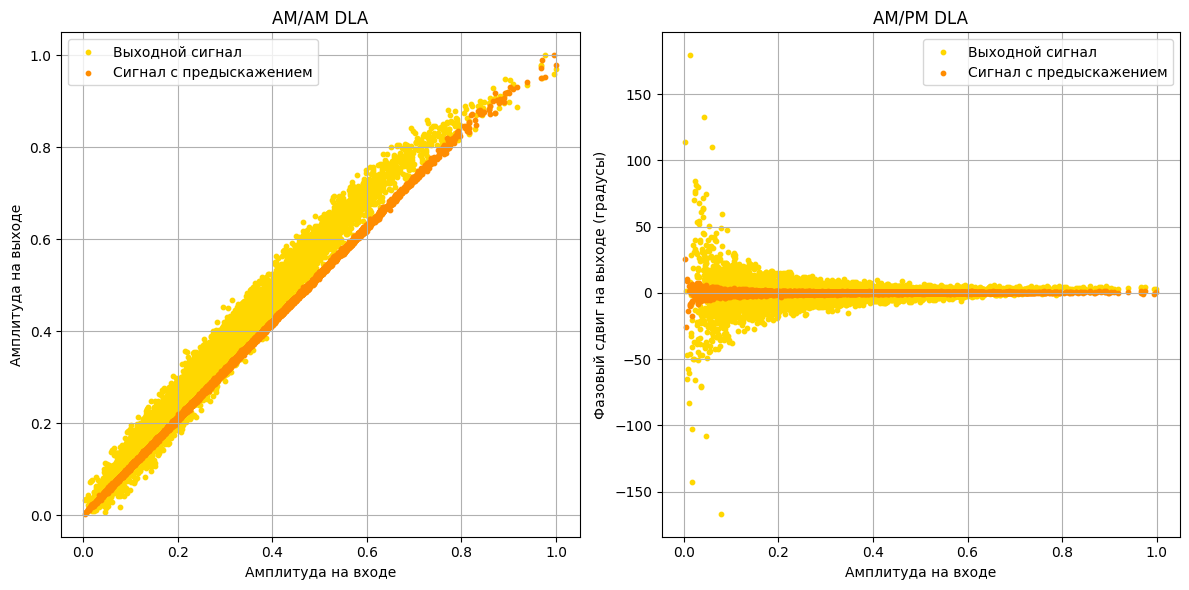

In [ ]:
#DLA

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_val_gru_dla_am_am, 'magenta', 'Сигнал на выходе DPD'),
    (y_in_am_am, y_val_gru_dla_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_val_gru_dla_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM DLA", "AM/PM DLA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)



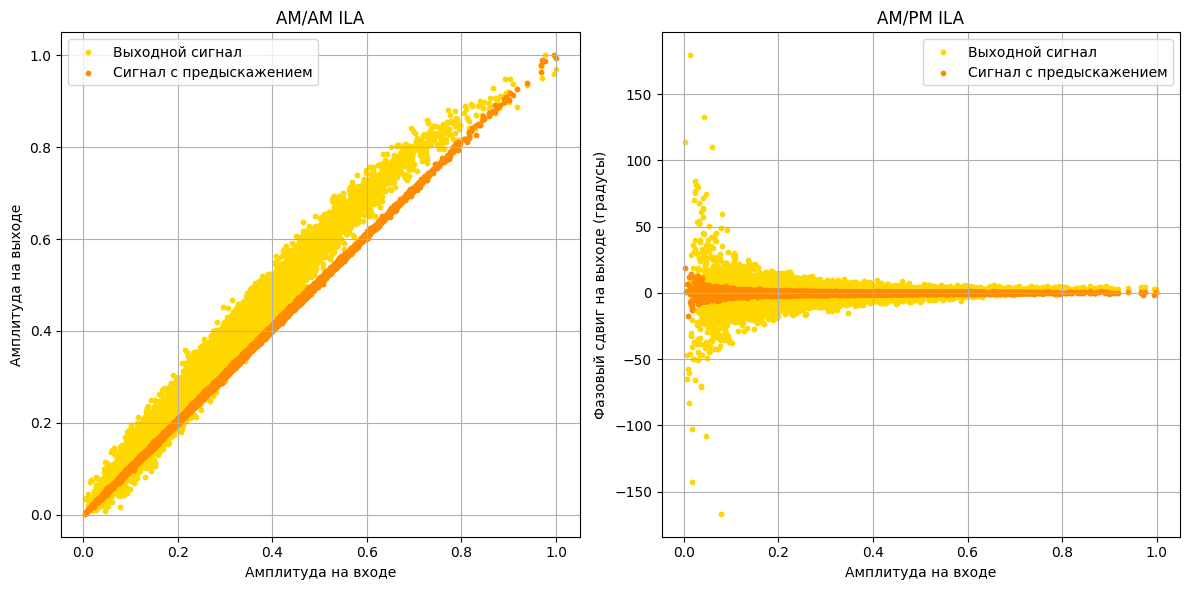

In [ ]:
#ILA

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_val_gru_ila_am_am, 'magenta', 'Сигнал на выходе DPD'),
    (y_in_am_am, y_val_gru_ila_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_val_gru_ila_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM ILA", "AM/PM ILA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)


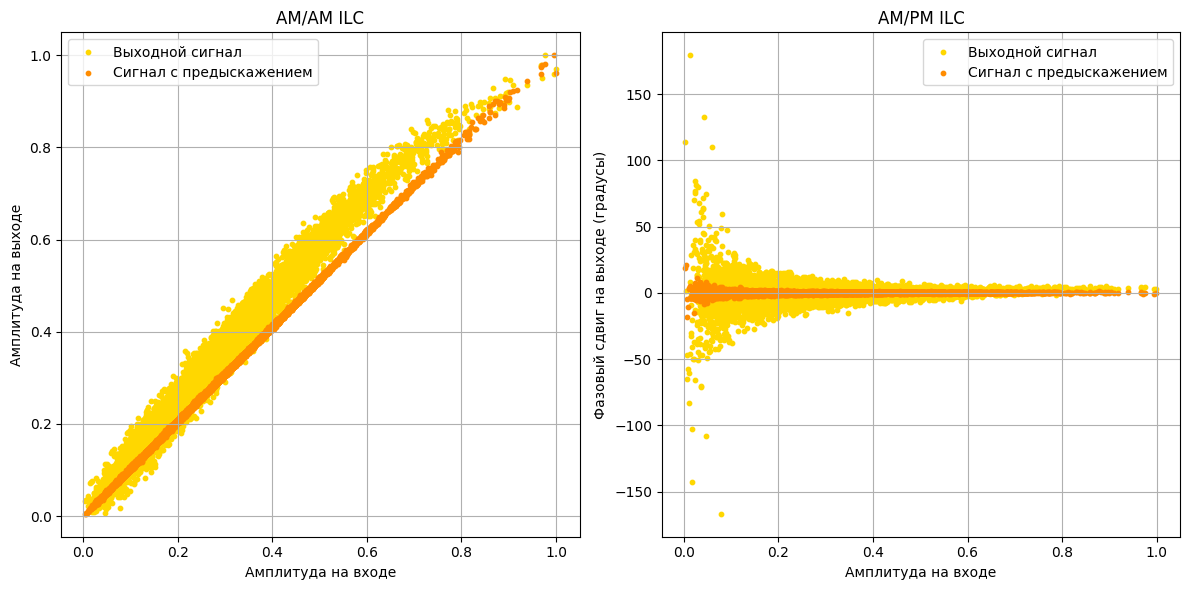

In [ ]:
#ILC

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_val_gru_ilc_am_am, 'magenta', 'Сигнал на выходе корректора'),
    (y_in_am_am, y_val_gru_ilc_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_val_gru_ilc_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM ILC", "AM/PM ILC"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)


Add noise

In [ ]:

snr_range = list(range(20, 61, 5))

epochs = 100
lr = 0.001
num_realizations = 200

hidden_size=8
num_layers=1


snr_params = params.make_snr_params(
    snr_range=snr_range,
    num_realizations=num_realizations,
    fs=fs,
    bw_main_ch=bw_main_ch,
    epochs=epochs,
    learning_rate=lr,
    acpr_meter=acpr_meter,
    pa_model=gru_pa,
    gain=gain
)

nn_params = {
    "hidden_size": hidden_size,
    "num_layers": num_layers
}

snr_metrics_runner = pipelines.SnrPipeline(base_model=GRU, 
                                           input_model_params=nn_params, 
                                           data_dict=data, 
                                           snr_params=snr_params)

In [ ]:
snr_metrics_runner.run_dla_noise()

SNR: 20
===Start training===
Epoch 0000 — train_loss: 0.079289, val_loss: 0.016323, val_NMSE: -16.79
Epoch 0049 — train_loss: 0.014882, val_loss: 0.014754, val_NMSE: -17.23
Время обучения: 0:01:28
===Training complete===
SNR: 25
===Start training===
Epoch 0000 — train_loss: 0.098993, val_loss: 0.005751, val_NMSE: -21.32
Epoch 0049 — train_loss: 0.004938, val_loss: 0.005057, val_NMSE: -21.88
Время обучения: 0:01:29
===Training complete===
SNR: 30
===Start training===
Epoch 0000 — train_loss: 0.070503, val_loss: 0.002585, val_NMSE: -24.80
Epoch 0049 — train_loss: 0.001667, val_loss: 0.001624, val_NMSE: -26.82
Время обучения: 0:01:28
===Training complete===
SNR: 35
===Start training===
Epoch 0000 — train_loss: 0.103375, val_loss: 0.002465, val_NMSE: -25.00
Epoch 0049 — train_loss: 0.000583, val_loss: 0.000549, val_NMSE: -31.53
Время обучения: 0:01:27
===Training complete===
SNR: 40
===Start training===
Epoch 0000 — train_loss: 0.074668, val_loss: 0.001108, val_NMSE: -28.47
Epoch 0049 — tr

In [ ]:
snr_metrics_runner.run_ila_noise()

SNR: 20
===Start training===
Epoch 0000 — train_loss: 0.016766, val_loss: 0.002250, val_NMSE: -17.37
Epoch 0049 — train_loss: 0.001898, val_loss: 0.001839, val_NMSE: -18.24
Время обучения: 0:01:08
===Training complete===
SNR: 25
===Start training===
Epoch 0000 — train_loss: 0.014179, val_loss: 0.000916, val_NMSE: -21.27
Epoch 0049 — train_loss: 0.000684, val_loss: 0.000642, val_NMSE: -22.81
Время обучения: 0:01:08
===Training complete===
SNR: 30
===Start training===
Epoch 0000 — train_loss: 0.016422, val_loss: 0.000622, val_NMSE: -22.96
Epoch 0049 — train_loss: 0.000252, val_loss: 0.000237, val_NMSE: -27.15
Время обучения: 0:01:08
===Training complete===
SNR: 35
===Start training===
Epoch 0000 — train_loss: 0.020940, val_loss: 0.000851, val_NMSE: -21.59
Epoch 0049 — train_loss: 0.000104, val_loss: 0.000087, val_NMSE: -31.50
Время обучения: 0:01:08
===Training complete===
SNR: 40
===Start training===
Epoch 0000 — train_loss: 0.026843, val_loss: 0.000824, val_NMSE: -21.73
Epoch 0049 — tr

In [ ]:
snr_metrics_runner.run_ilc_noise()

SNR: 20
Epoch [0/200], Loss: 0.05504428967833519
Epoch [100/200], Loss: 0.0163440965116024
Epoch [199/200], Loss: 0.01662500575184822
Время расчёта ilc_signal: 0:12:49
===Start training===
Epoch 0000 — train_loss: 0.008179, val_loss: 0.072946, val_NMSE: 0.15
Epoch 0049 — train_loss: 0.000178, val_loss: 0.072638, val_NMSE: 0.13
Время обучения: 0:00:49
===Training complete===
SNR: 25
Epoch [0/200], Loss: 0.038476452231407166
Epoch [100/200], Loss: 0.005731415934860706
Epoch [199/200], Loss: 0.005766578484326601
Время расчёта ilc_signal: 0:12:47
===Start training===
Epoch 0000 — train_loss: 0.014055, val_loss: 0.075401, val_NMSE: 0.06
Epoch 0049 — train_loss: 0.000118, val_loss: 0.076817, val_NMSE: 0.14
Время обучения: 0:00:50
===Training complete===
SNR: 30
Epoch [0/200], Loss: 0.03320373594760895
Epoch [100/200], Loss: 0.0020090616308152676
Epoch [199/200], Loss: 0.002058345125988126
Время расчёта ilc_signal: 0:12:51
===Start training===
Epoch 0000 — train_loss: 0.011876, val_loss: 0.07

In [ ]:
results = snr_metrics_runner.get_results()

snr_range = results["snr_range"]

nmse_dla_list = results["dla"]["nmse"]
acpr_left_dla_list = results["dla"]["acpr_left"]
acpr_right_dla_list = results["dla"]["acpr_right"]

nmse_ila_list = results["ila"]["nmse"]
acpr_left_ila_list = results["ila"]["acpr_left"]
acpr_right_ila_list = results["ila"]["acpr_right"]

nmse_ilc_list = results["ilc"]["nmse"]
acpr_left_ilc_list = results["ilc"]["acpr_left"]
acpr_right_ilc_list = results["ilc"]["acpr_right"]

nmse_uk_list = results["uk"]["nmse"]
acpr_left_uk_list = results["uk"]["acpr_left"]
acpr_right_uk_list = results["uk"]["acpr_right"]

In [ ]:
print(f"snr_range = {snr_range}")
print()

print(f"nmse_dla_list = {(nmse_dla_list)}")
print(f"acpr_left_dla_list = {acpr_left_dla_list}")
print(f"acpr_right_dla_list = {acpr_right_dla_list}")
print()

print(f"nmse_ila_list = {nmse_ila_list}")
print(f"acpr_left_ila_list = {acpr_left_ila_list}")
print(f"acpr_right_ila_list = {acpr_right_ila_list}")
print()

print(f"nmse_ilc_list = {nmse_ilc_list}")
print(f"acpr_left_ilc_list = {acpr_left_ilc_list}")
print(f"acpr_right_ilc_list = {acpr_right_ilc_list}")
print()

print(f"nmse_uk_list = {nmse_uk_list}")
print(f"acpr_left_uk_list = {acpr_left_uk_list}")
print(f"acpr_right_uk_list = {acpr_right_uk_list}")

snr_range = [20, 25, 30, 35, 40, 45, 50, 55, 60]

nmse_dla_list = [-17.137060165405273, -21.96965980529785, -26.81765365600586, -31.505434036254883, -35.57054138183594, -38.63620376586914, -39.113792419433594, -38.6195068359375, -41.02045822143555]
acpr_left_dla_list = [np.float64(-20.043180907001865), np.float64(-24.997615366869727), np.float64(-29.88420059459173), np.float64(-34.69813351874072), np.float64(-39.11869853930988), np.float64(-42.75941617564841), np.float64(-44.556015439067544), np.float64(-45.50579331757665), np.float64(-45.856063390816914)]
acpr_right_dla_list = [np.float64(-20.03768970456767), np.float64(-24.98483819339822), np.float64(-29.91008171158717), np.float64(-34.66632986010521), np.float64(-39.092701210139325), np.float64(-42.551257239684695), np.float64(-44.15280496551297), np.float64(-45.29853879521245), np.float64(-46.00348917956039)]

nmse_ila_list = [-16.82413673400879, -21.81842613220215, -26.752714157104492, -31.452070236206055, -35.70893096923828, -34.

In [ ]:
# # значения в виде списков чтобы не рассчитывать снова все значения

# snr_range = [20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]

# nmse_dla_list = [-14.1044340133667, -16.018064498901367, -17.97743797302246, -19.84555435180664, -21.76476287841797, -23.601543426513672, -25.397140502929688, -27.051654815673828, -28.60270118713379, -29.951904296875, -31.10137939453125, -31.99922752380371, -32.693359375, -33.20136260986328, -33.556922912597656, -33.7752571105957, -33.94951248168945, -34.041229248046875, -34.11683654785156, -34.161094665527344, -34.18443298339844]
# acpr_left_dla_list = [-19.98307782854365, -22.044059761313314, -24.047040241882005, -25.981348959580895, -27.975370600038946, -29.942117343851447, -31.96514345661867, -33.80510011678665, -35.72137883607495, -37.63892721922215, -39.546686668811134, -41.14783435664147, -42.72300193647455, -44.1586403570728, -45.36636102368466, -46.3075550113637, -47.042928773938236, -47.62786795374185, -48.053632118082476, -48.26038054693791, -48.41887604347718]
# acpr_right_dla_list = [-20.041831052899113, -21.95478038014439, -23.98363774561688, -25.910596158467115, -27.91143197214374, -29.830851608311, -31.79363647332617, -33.5694401253062, -35.43604753655994, -37.07000947388168, -38.589720264578695, -39.981493718118756, -41.18240060456666, -42.0034433292463, -42.727465426518414, -43.28342016300996, -43.61496527628741, -43.81084719101566, -43.98201861121989, -44.08200476372817, -44.162913038570224]

# nmse_ila_list = [-13.854040145874023, -15.777467727661133, -17.762771606445312, -19.657350540161133, -21.58496856689453, -23.4307918548584, -25.17462730407715, -26.818567276000977, -28.340505599975586, -29.61135482788086, -30.697265625, -31.556087493896484, -32.22067642211914, -32.64470291137695, -32.968238830566406, -33.183040618896484, -33.31875991821289, -33.422943115234375, -33.47233963012695, -33.510684967041016, -33.5294189453125]
# acpr_left_ila_list = [-20.027768364406164, -22.02595135920506, -23.98453820660988, -25.961216816485567, -27.89464166886246, -29.93190200512903, -31.88604293318803, -33.82673998661604, -35.772038392214476, -37.61613725169961, -39.35554674161212, -40.999545012141596, -42.574679365583734, -43.93042452256015, -45.03867510014294, -45.908987401819914, -46.56702971768967, -47.03977254628908, -47.41264367177677, -47.67963051393086, -47.772995960135724]
# acpr_right_ila_list = [-19.930579122305584, -21.869039603483063, -23.92589430272745, -25.8934186825347, -27.89435768624694, -29.824054115245037, -31.657192539039386, -33.574507705349546, -35.29508665583067, -36.91289391444029, -38.35332621280914, -39.531460585547265, -40.53575407057057, -41.37233528658536, -41.93340984815785, -42.33601701225255, -42.63072372715388, -42.78626262772036, -42.906565042070014, -42.98986099019487, -43.06106380151427]

# nmse_ilc_list = [-14.0765962600708, -16.038497924804688, -17.95038604736328, -19.846113204956055, -21.75259017944336, -23.631811141967773, -25.368045806884766, -27.051647186279297, -28.601642608642578, -29.968273162841797, -31.0953426361084, -32.05195999145508, -32.759464263916016, -33.242897033691406, -33.58929443359375, -33.86418914794922, -34.00400924682617, -34.103553771972656, -34.197731018066406, -34.209129333496094, -34.251609802246094]
# acpr_left_ilc_list = [-19.987904634237463, -22.032664265763948, -23.981805945312637, -25.985078180439405, -27.97285318573928, -29.932254292413706, -31.93950622504634, -33.871982256476386, -35.687000986372624, -37.643129058194496, -39.36068479051006, -41.063457267103004, -42.61319314281078, -43.93533817262031, -45.077593707598375, -46.05866500876228, -46.68572673296391, -47.206334708000576, -47.541040851625766, -47.77248651232119, -47.95394808902196]
# acpr_right_ilc_list = [-19.970945068810845, -21.99232485637614, -23.99870022329292, -25.8777047238745, -27.85245425738548, -29.870087979042914, -31.71947716771799, -33.548264032512904, -35.38769115623252, -36.93997367595692, -38.44486643405877, -39.832029876134314, -40.894418612291034, -41.675168206028694, -42.37802985442333, -42.748574412828496, -43.07917614846056, -43.318133130296104, -43.473543736876735, -43.543050561279685, -43.59642567165372]

# nmse_uk_list = [-14.0831298828125, -16.007923126220703, -17.956777572631836, -19.8975887298584, -21.878353118896484, -23.844219207763672, -25.788644790649414, -27.7381649017334, -29.701080322265625, -31.64846420288086, -33.609657287597656, -35.53433609008789, -37.480770111083984, -39.428749084472656, -41.34610366821289, -43.275142669677734, -45.19207000732422, -47.10540771484375, -48.99323654174805, -50.86845397949219, -52.7203369140625]
# acpr_left_uk_list = [-19.998392505893012, -21.96503696465798, -23.970991167027375, -25.9149880083065, -27.92604114808463, -29.87986846158727, -31.819333935519474, -33.75500066095982, -35.68040463397734, -37.580494422986966, -39.43423352610119, -41.25160083392008, -42.91737743348149, -44.5111827081357, -45.92210941660184, -47.14031506566594, -48.14644265515601, -48.92050801676599, -49.54857485864436, -49.93755700347053, -50.273354378725]
# acpr_right_uk_list = [-19.893920065196465, -21.86624051842887, -23.84565607408318, -25.75388263544563, -27.70074723690906, -29.627564553190144, -31.569643994482238, -33.43726278691267, -35.32040951826972, -37.142184428452595, -38.9831850829623, -40.66346961805266, -42.32750364604643, -43.85724713876513, -45.296073869065694, -46.486982373361776, -47.48990958237207, -48.29148483835154, -48.9249656987649, -49.38223862798154, -49.67895177822955]

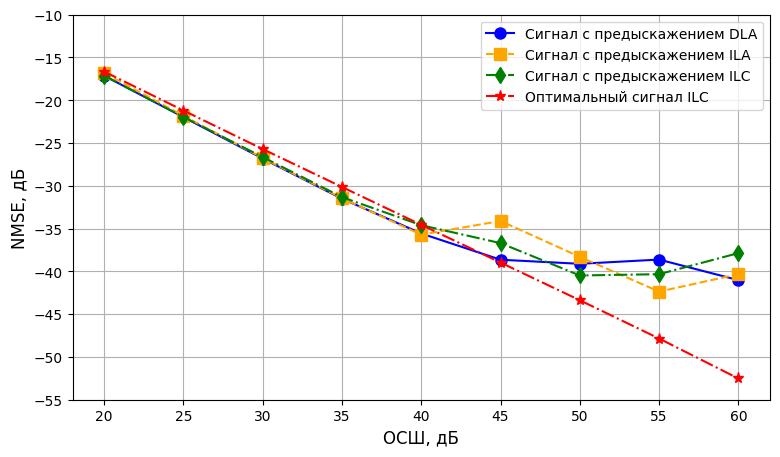

In [ ]:
markersize = 8
plt.figure(figsize=(9, 5))
plt.plot(snr_range, nmse_dla_list,color='blue', linestyle='-', label="Сигнал с предыскажением DLA",
         marker='o', markersize=markersize)
plt.plot(snr_range, nmse_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA",
         marker='s', markersize=markersize)
plt.plot(snr_range, nmse_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC",
         marker='d', markersize=markersize)
plt.plot(snr_range, nmse_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC",
         marker='*', markersize=markersize)

plt.xlabel("ОСШ, дБ", fontsize=12)
plt.ylabel("NMSE, дБ", fontsize=12)
# plt.title("Зависимость NMSE от ОСШ")
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -9, 5))
plt.legend()
plt.grid(True)

plt.show()


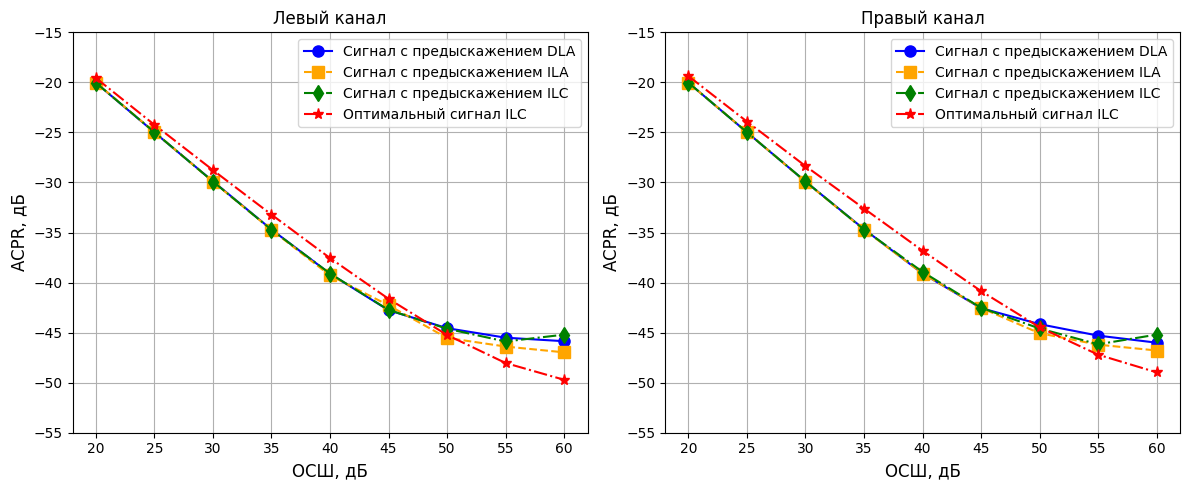

In [ ]:
markersize=8
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# plt.plot(snr_range, acpr_left_dla_list, marker='o', color='blue', linestyle='-', label="Сигнал с предыскажением DLA")
# plt.plot(snr_range, acpr_left_ila_list, marker='s', color='orange', linestyle='--', label="Сигнал с предыскажением ILA")
# plt.plot(snr_range, acpr_left_ilc_list, marker='d', color='green', linestyle='-.', label="Сигнал с предыскажением ILC")
# plt.plot(snr_range, acpr_left_uk_list, marker='*', color='indigo', linestyle='-.', label="Оптимальный сигнал ILC")
plt.plot(snr_range, acpr_left_dla_list, color='blue', linestyle='-', label="Сигнал с предыскажением DLA", 
         marker='o', markersize=markersize)
plt.plot(snr_range, acpr_left_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA", 
         marker='s', markersize=markersize)
plt.plot(snr_range, acpr_left_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC", 
         marker='d', markersize=markersize)
plt.plot(snr_range, acpr_left_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC", 
         marker='*', markersize=markersize)
plt.title('Левый канал', fontsize=12)
plt.xlabel('ОСШ, дБ', fontsize=12)
plt.ylabel('ACPR, дБ', fontsize=12)
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -14, 5))
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(snr_range, acpr_right_dla_list, color='blue', linestyle='-', label="Сигнал с предыскажением DLA", 
         marker='o', markersize=markersize)
plt.plot(snr_range, acpr_right_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA", 
         marker='s', markersize=markersize)
plt.plot(snr_range, acpr_right_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC", 
         marker='d', markersize=markersize)
plt.plot(snr_range, acpr_right_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC", 
         marker='*', markersize=markersize)
plt.title('Правый канал', fontsize=12)
plt.xlabel('ОСШ, дБ', fontsize=12)
plt.ylabel('ACPR, дБ', fontsize=12)
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -14, 5))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()